# 1.环境准备和数据加载

首先，导入必要的Python库，并加载数据。

In [25]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 Matplotlib 和 Seaborn 风格，使图表更美观
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

# 设置中文字体，Windows 系统中一般可以使用 'SimHei' 字体
plt.rcParams['font.family'] = 'SimHei'

# 获取当前脚本的路径
current_dir = os.getcwd()

# 文件夹路径
data_path = os.path.join(current_dir, '..', 'output')

# 加载数据
data_path_combined = os.path.join(data_path, 'combined_data.pkl')
combined_data = pd.read_pickle(data_path_combined)

print(f"数据加载完成，数据量: {len(combined_data)}")

数据加载完成，数据量: 17704927


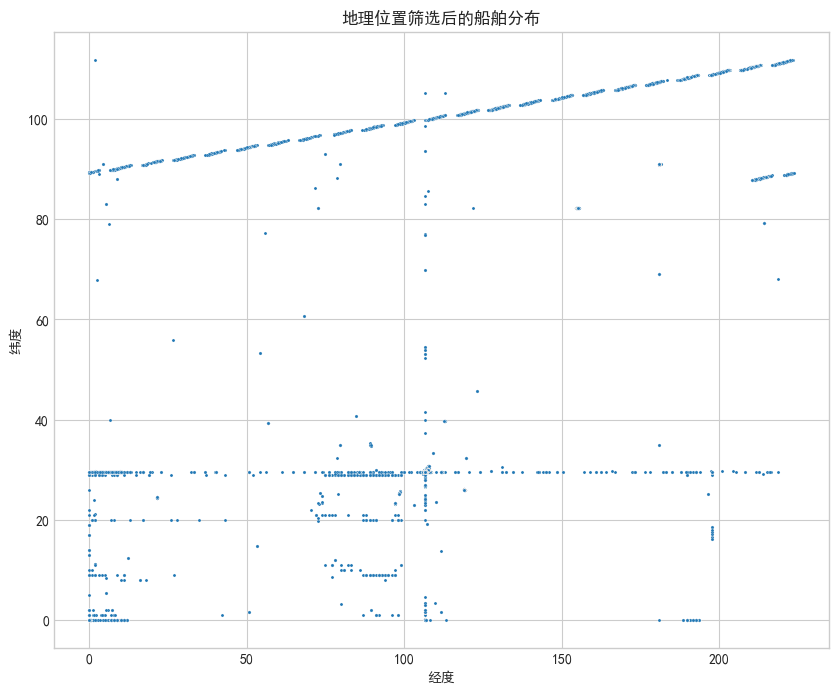

In [26]:
# 可视化所有数据 - 散点图
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', data=combined_data, s=5) # s=5 调整点的大小
plt.title('地理位置筛选后的船舶分布')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.show()

# 2.初步地理位置筛选及可视化



地理位置筛选后数据量: 17018409


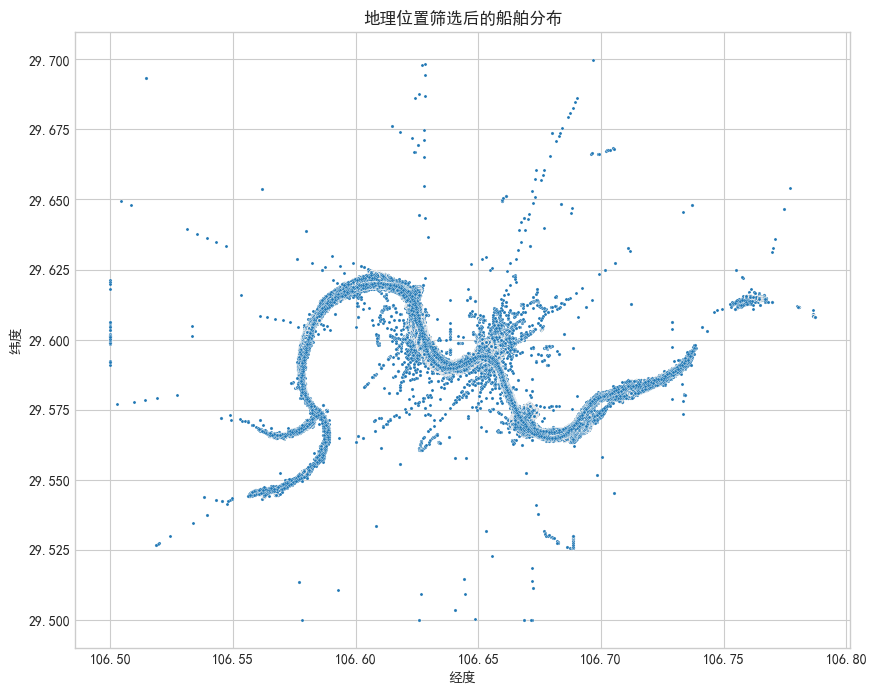

In [14]:
# 定义地理边界
lon_min = 106.5
lon_max = 106.8
lat_min = 29.5
lat_max = 29.7

# 地理位置筛选函数
def process_data_geo_filter(data):
    # 1. 筛选数据
    data = data[(data['longitude'] >= lon_min) & (data['longitude'] <= lon_max) & (data['latitude'] >= lat_min) & (data['latitude'] <= lat_max)]
    # 2. 返回筛选后的数据
    return data

# 执行地理位置筛选
filtered_data_geo = process_data_geo_filter(combined_data.copy()) # 使用 .copy() 避免修改原始 DataFrame

print(f"地理位置筛选后数据量: {len(filtered_data_geo)}")

# 可视化地理位置筛选结果 - 散点图
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', data=filtered_data_geo, s=5) # s=5 调整点的大小
plt.title('地理位置筛选后的船舶分布')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.show()

# 3.缺失值处理

缺失值统计:
 mmsi         1
longitude    0
latitude     0
cog          0
sog          0
post_time    0
dtype: int64


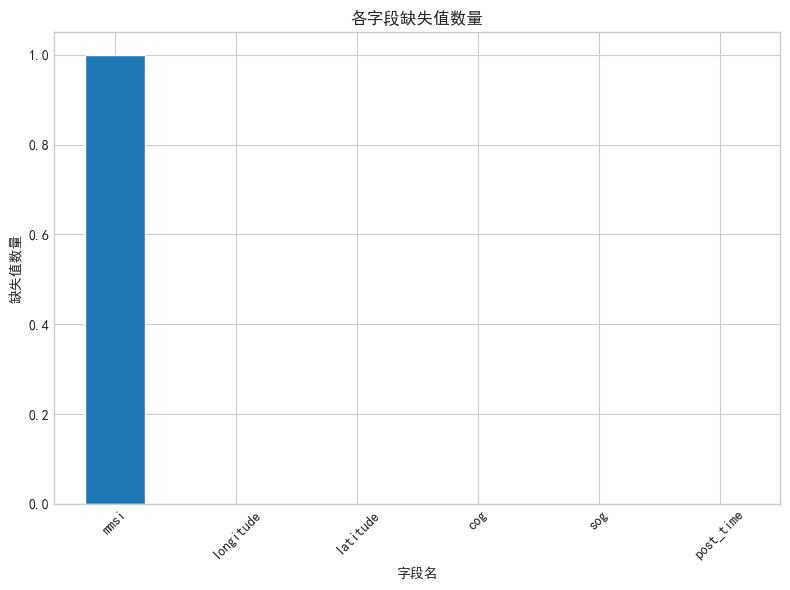

删除缺失值后数据量: 17018408

删除缺失值后缺失值统计 (应为0):
 mmsi         0
longitude    0
latitude     0
cog          0
sog          0
post_time    0
dtype: int64


In [15]:
# 检查缺失值
missing_values = filtered_data_geo.isnull().sum()
print("缺失值统计:\n", missing_values)

# 可视化缺失值 - 条形图
missing_values.plot(kind='bar', figsize=(8, 6))
plt.title('各字段缺失值数量')
plt.xlabel('字段名')
plt.ylabel('缺失值数量')
plt.xticks(rotation=45) # 旋转 X 轴标签，使其可读
plt.tight_layout() # 自动调整子图参数，使图形适应区域
plt.show()

# 处理缺失值 - 删除包含缺失值的行 (这里为了简化演示，实际情况需根据缺失情况和数据量决定处理策略)
filtered_data_no_missing = filtered_data_geo.dropna()
print(f"删除缺失值后数据量: {len(filtered_data_no_missing)}")

# 再次检查缺失值 (确认已处理)
missing_values_after_dropna = filtered_data_no_missing.isnull().sum()
print("\n删除缺失值后缺失值统计 (应为0):\n", missing_values_after_dropna)

# 4.异常值处理 - 速度异常

为什么会有这么高的值

后面选几个跑得快的看看

todo: 将简单删除改为替换为前后值的平均值

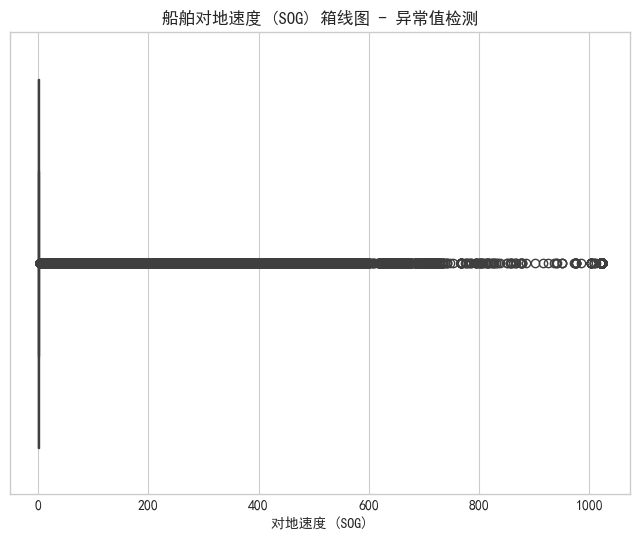

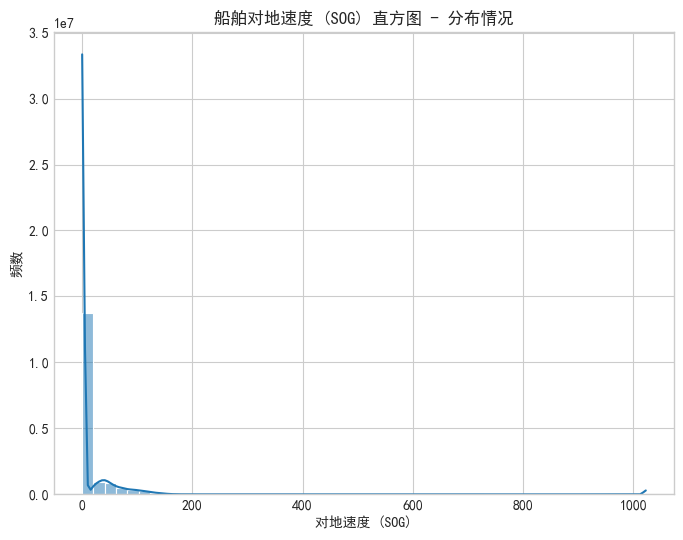

速度异常值处理后数据量: 16883328


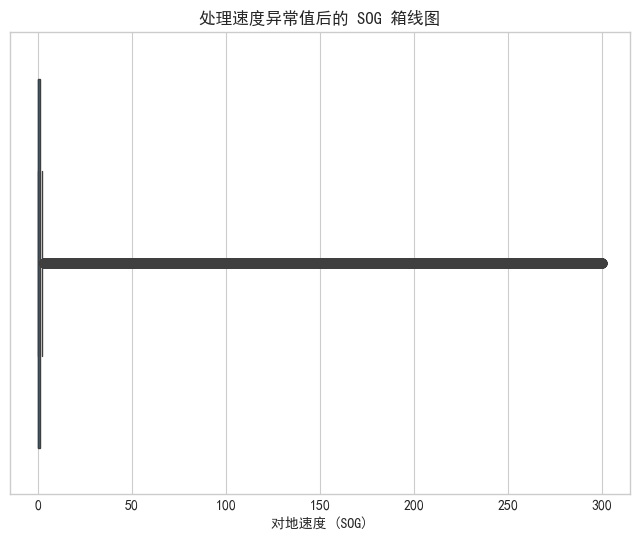

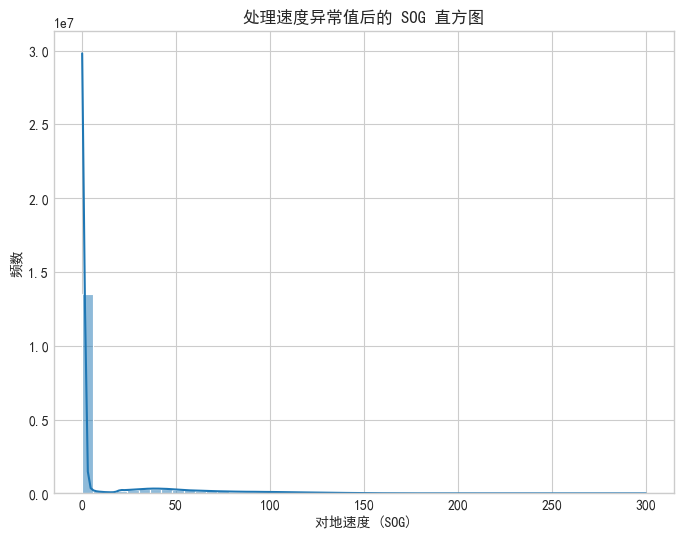

In [19]:
# 速度 (SOG) 异常值检测 - 箱线图
plt.figure(figsize=(8, 6))
sns.boxplot(x=filtered_data_no_missing['sog'])
plt.title('船舶对地速度 (SOG) 箱线图 - 异常值检测')
plt.xlabel('对地速度 (SOG)')
plt.show()

# 速度 (SOG) 异常值检测 - 直方图
plt.figure(figsize=(8, 6))
sns.histplot(filtered_data_no_missing['sog'], bins=50, kde=True) # bins=50 调整柱子数量, kde=True 显示核密度估计曲线
plt.title('船舶对地速度 (SOG) 直方图 - 分布情况')
plt.xlabel('对地速度 (SOG)')
plt.ylabel('频数')
plt.show()


# 处理速度 (SOG) 异常值 -  设定速度上限，例如 30 节 (根据实际船舶类型和应用场景调整)
speed_threshold = 300
filtered_data_speed_outlier = filtered_data_no_missing[filtered_data_no_missing['sog'] <= speed_threshold].copy()
print(f"速度异常值处理后数据量: {len(filtered_data_speed_outlier)}")


# 再次可视化速度 (SOG) - 箱线图 (处理后)
plt.figure(figsize=(8, 6))
sns.boxplot(x=filtered_data_speed_outlier['sog'])
plt.title('处理速度异常值后的 SOG 箱线图')
plt.xlabel('对地速度 (SOG)')
plt.show()

# 再次可视化速度 (SOG) - 直方图 (处理后)
plt.figure(figsize=(8, 6))
sns.histplot(filtered_data_speed_outlier['sog'], bins=50, kde=True)
plt.title('处理速度异常值后的 SOG 直方图')
plt.xlabel('对地速度 (SOG)')
plt.ylabel('频数')
plt.show()

# 5.异常值处理 - 航向异常

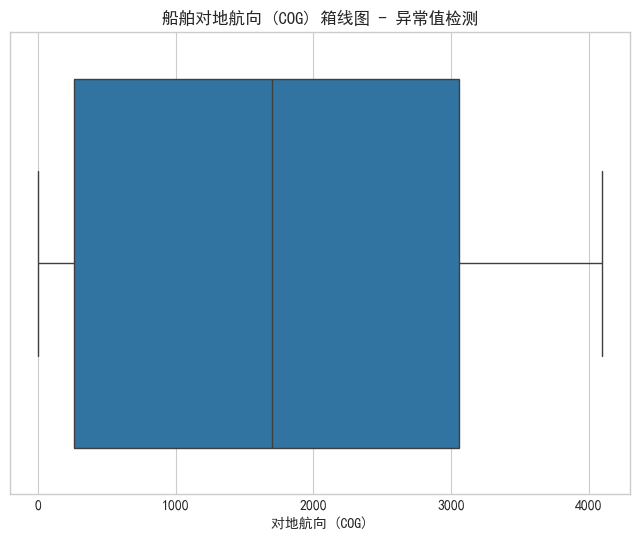

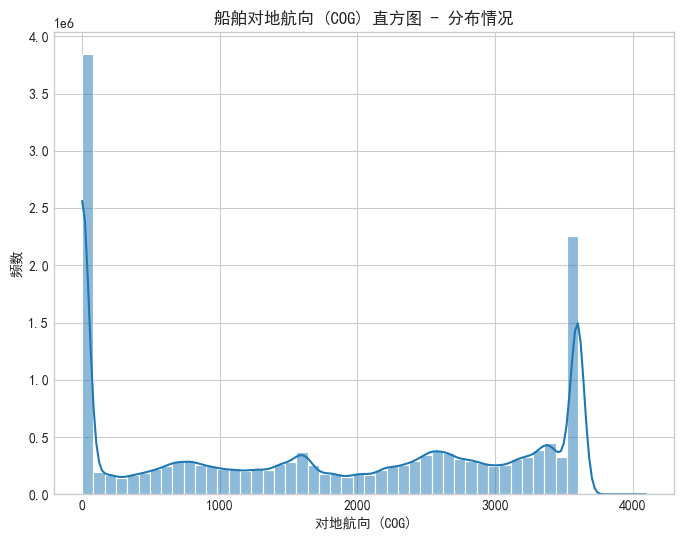

航向异常值处理后数据量: 16883257


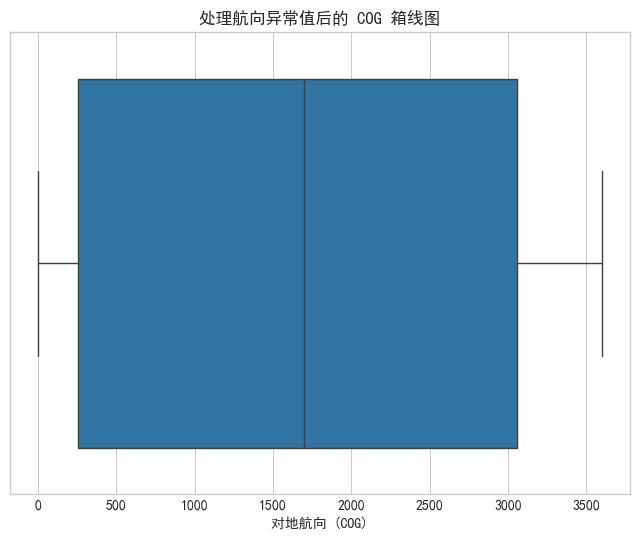

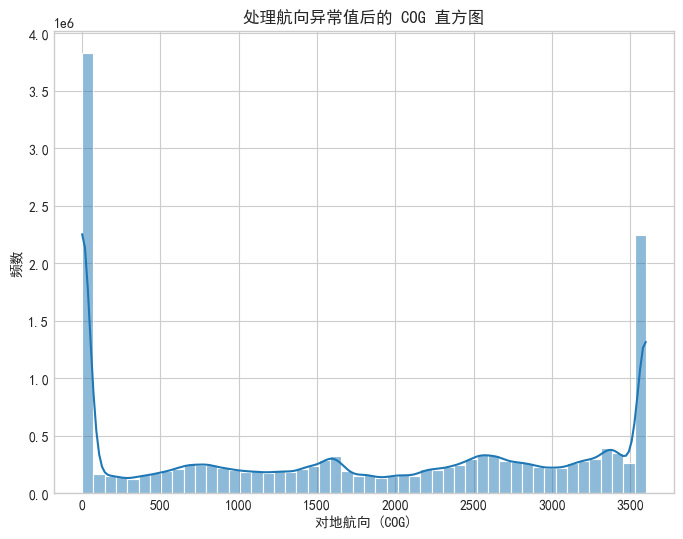

In [20]:
# 航向 (COG) 异常值检测 - 箱线图
plt.figure(figsize=(8, 6))
sns.boxplot(x=filtered_data_speed_outlier['cog'])
plt.title('船舶对地航向 (COG) 箱线图 - 异常值检测')
plt.xlabel('对地航向 (COG)')
plt.show()

# 航向 (COG) 异常值检测 - 直方图
plt.figure(figsize=(8, 6))
sns.histplot(filtered_data_speed_outlier['cog'], bins=50, kde=True)
plt.title('船舶对地航向 (COG) 直方图 - 分布情况')
plt.xlabel('对地航向 (COG)')
plt.ylabel('频数')
plt.show()


# 处理航向 (COG) 异常值 - 航向值应该在 0-360 度范围内
filtered_data_cog_outlier = filtered_data_speed_outlier[(filtered_data_speed_outlier['cog'] >= 0) & (filtered_data_speed_outlier['cog'] <= 3600)].copy()
print(f"航向异常值处理后数据量: {len(filtered_data_cog_outlier)}")


# 再次可视化航向 (COG) - 箱线图 (处理后)
plt.figure(figsize=(8, 6))
sns.boxplot(x=filtered_data_cog_outlier['cog'])
plt.title('处理航向异常值后的 COG 箱线图')
plt.xlabel('对地航向 (COG)')
plt.show()

# 再次可视化航向 (COG) - 直方图 (处理后)
plt.figure(figsize=(8, 6))
sns.histplot(filtered_data_cog_outlier['cog'], bins=50, kde=True)
plt.title('处理航向异常值后的 COG 直方图')
plt.xlabel('对地航向 (COG)')
plt.ylabel('频数')
plt.show()

# 6.重复值处理

In [21]:
# 检测重复值
duplicate_rows = filtered_data_cog_outlier.duplicated()
print(f"重复值数量: {duplicate_rows.sum()}")

# 可视化重复值 (如果数量不多，可以简单打印出来查看)
if duplicate_rows.sum() > 0 and duplicate_rows.sum() < 10: # 如果重复值少于10条，打印出来查看
    print("重复值示例:\n", filtered_data_cog_outlier[duplicate_rows])


# 处理重复值 - 删除重复行
filtered_data_no_duplicates = filtered_data_cog_outlier.drop_duplicates().copy()
print(f"删除重复值后数据量: {len(filtered_data_no_duplicates)}")

# 再次检测重复值 (确认已处理)
duplicate_rows_after_drop = filtered_data_no_duplicates.duplicated()
print(f"删除重复值后重复值数量 (应为 0): {duplicate_rows_after_drop.sum()}")

重复值数量: 1004
删除重复值后数据量: 16882253
删除重复值后重复值数量 (应为 0): 0


# 7.数据保存

In [22]:
filtered_data = filtered_data_no_duplicates.copy() # 保存处理后的数据

data_path_filtered = os.path.join(data_path, 'filtered_data.pkl')

# 保存处理后的数据
filtered_data.to_pickle(data_path_filtered)

print(f"处理后的数据已保存至: {data_path_filtered}")


处理后的数据已保存至: C:\Projects\PycharmProjects\inland-ship-predict\scripts\..\output\filtered_data.pkl


预处理后数据量: 16882253


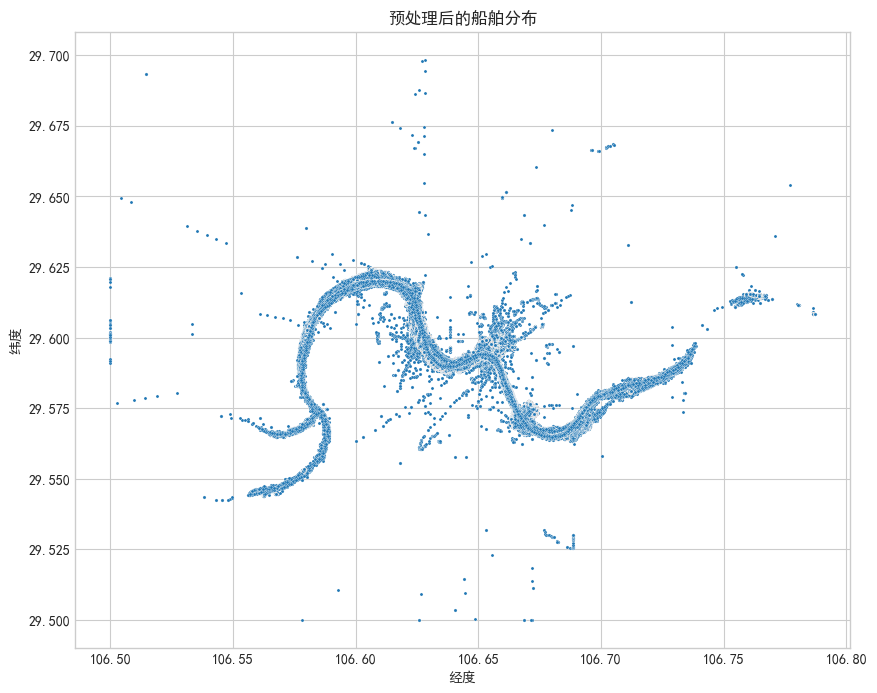

In [23]:
print(f"预处理后数据量: {len(filtered_data)}")

# 可视化预处理结果 - 散点图
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', data=filtered_data, s=5) # s=5 调整点的大小
plt.title('预处理后的船舶分布')
plt.xlabel('经度')
plt.ylabel('纬度')
plt.show()